<h1><center>Model variations - Phase transition</center></h1>
<center>This notebook purpose is to illustrate and analyze the potential phase transition of three model variations<center>

In [7]:
import numpy as np
import pandas as pd
import utils
from models import AnnLassoRegression
from tqdm import tqdm
import time

In [8]:
model_no_warmstart = AnnLassoRegression(name = "without warm start", warm_start=False, last_ista=30000)
model_warmstart_ista = AnnLassoRegression(name = "warm start, ista at each sd", warm_start=True, one_ista=False, last_ista=30000)
model_warmstart_no_ista = AnnLassoRegression(name = "warm start, ista only at end", warm_start=True, one_ista=True, last_ista=30000)

In [ ]:
pesr_history_no_warmstart = {i: [] for i in range(1, 18)}
pesr_history_warmstart_ista = {i: [] for i in range(1, 18)}
pesr_history_warmstart_no_ista = {i: [] for i in range(1, 18)}

time_history_no_warmstart, time_history_warmstart_ista, time_history_warmstart_no_ista = [], [], []

for j in range(1, 5):
    for i in tqdm(range(1, 18), desc="Number of features progress"):
        X_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets/dataSets{j}/s{i}/train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets/dataSets{j}/s{i}/test-y.csv", header = None)

        features = pd.read_csv(f"dataSets/dataSets{j}/s{i}/important_inds.csv")
        features = features.values.flatten()

        t=time.time()
        model_no_warmstart.fit(X_train, y_train, print_epochs=False)
        time_history_no_warmstart.append(time.time()-t)
        pesr_history_no_warmstart[i].append(model_no_warmstart.results_analysis(X_test, y_test, features)['exact_recovery'])

        t=time.time()
        model_warmstart_ista.fit(X_train, y_train, print_epochs=False)
        time_history_warmstart_ista.append(time.time()-t)
        pesr_history_warmstart_ista[i].append(model_warmstart_ista.results_analysis(X_test, y_test, features)['exact_recovery'])

        t=time.time()
        model_warmstart_no_ista.fit(X_train, y_train, print_epochs=False)
        time_history_warmstart_no_ista.append(time.time()-t)
        pesr_history_warmstart_no_ista[i].append(model_warmstart_no_ista.results_analysis(X_test, y_test, features)['exact_recovery'])

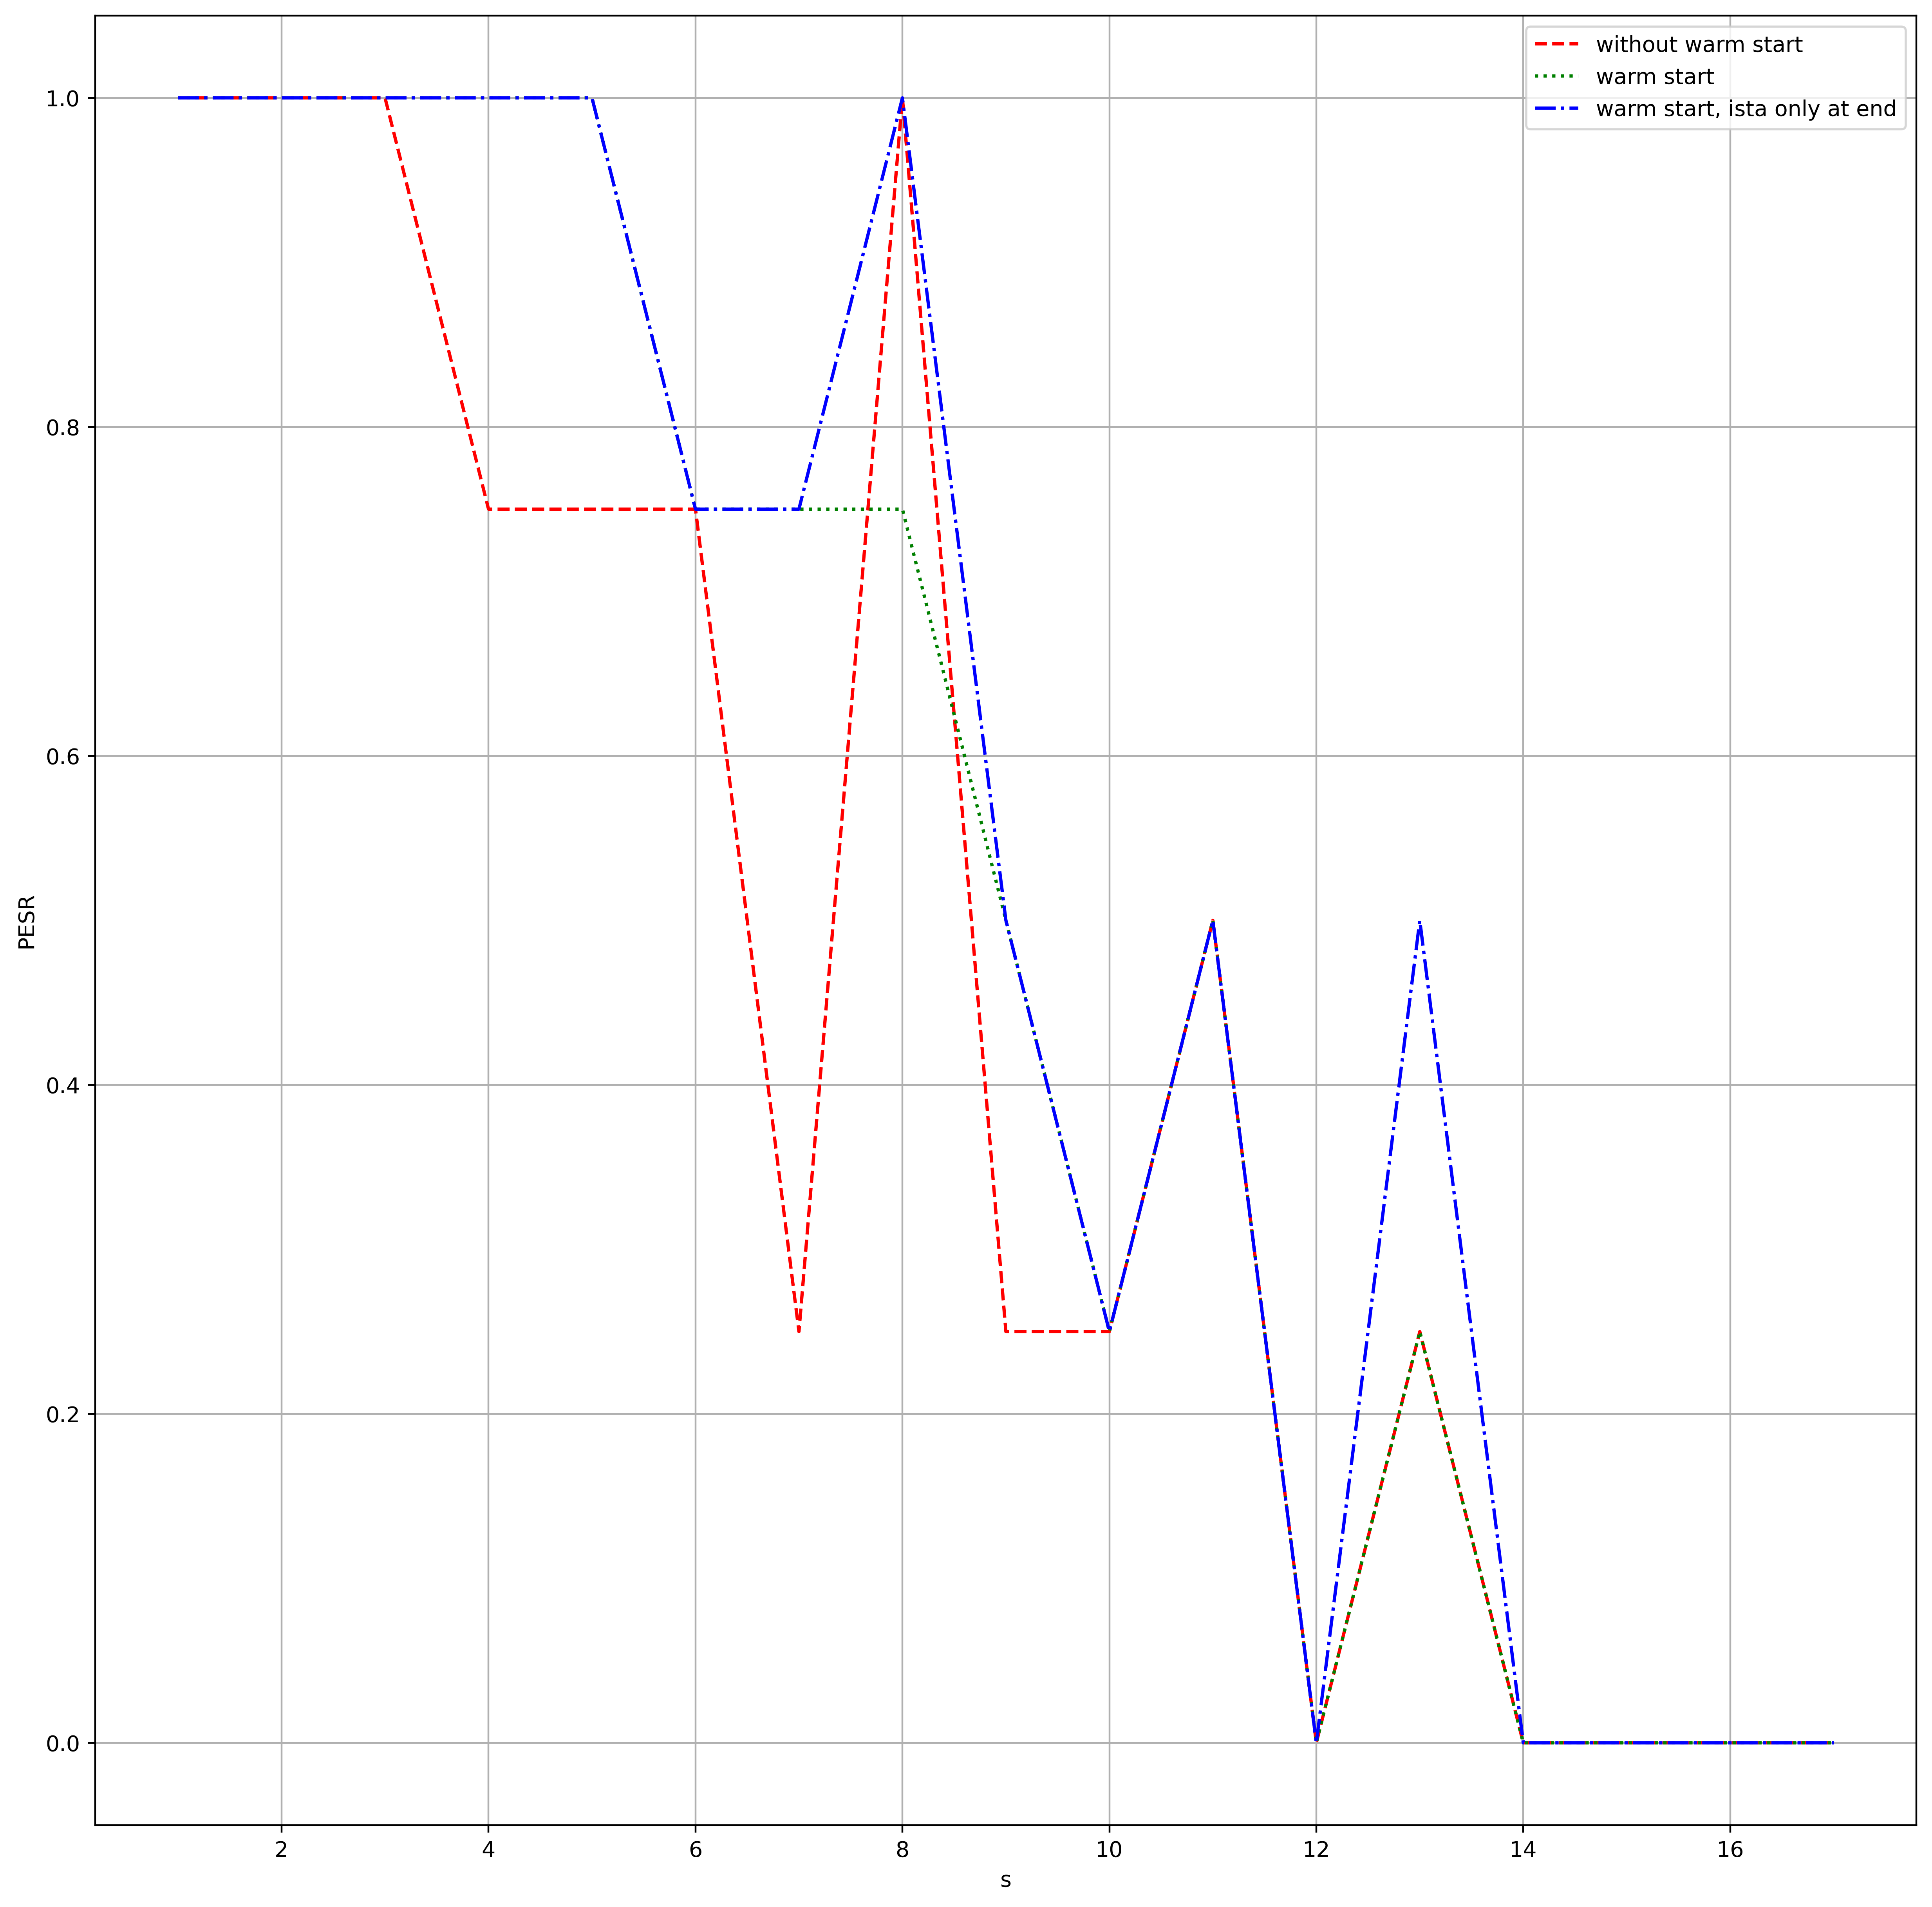

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15), dpi=400)
ran = np.arange(1, 18)
mean_no_warm_start = [np.mean(pesr_history_no_warmstart[i]) for i in ran]
mean_warm_start_ista= [np.mean(pesr_history_warmstart_ista[i]) for i in ran]
mean_warm_start_no_ista= [np.mean(pesr_history_warmstart_no_ista[i]) for i in ran]

plt.ylabel("PESR")
plt.xlabel("s")
plt.plot(ran, mean_no_warm_start, color='red', linestyle='dashed', label='without warm start')
plt.plot(ran, mean_warm_start_ista, color='green', linestyle='dotted',label='warm start')
plt.plot(ran, mean_warm_start_no_ista, color='blue', linestyle='dashdot', label='warm start, ista only at end')
plt.grid(True)
plt.legend()
plt.show()